# Customer Churn Prediction
## Notebook 7 of 8 — Model Improvement

This project predicts which telecom customers are likely to **churn** (cancel their service) so the business can reach them with retention offers *before* they leave. The eight notebooks run in order: exploration, cleaning, EDA, feature engineering, a baseline model, evaluation, improvement, and the final model.

**Business problem:** Keeping an existing customer costs less than winning a new one. This telecom loses about **27% of its customers**, so the question is which of them to spend a retention offer on.

This is a portfolio project built on a public dataset. There is no real client, and the 70% recall target used later is one I set myself.

**Tools:** Python · pandas · Matplotlib · Seaborn · scikit-learn · XGBoost · SMOTE (imbalanced-learn) · joblib

> **This notebook:** we systematically push recall up — trying Random Forest and XGBoost, fixing the class imbalance with SMOTE, and tuning the decision threshold.

**Author:** La Yaung Linn Lett  &nbsp;·&nbsp;  **Last updated:** August 2026

---

## 1. Setup

**What:** Load the model-ready data and create the same train/test split used everywhere else.

**Why:** Using an identical split keeps every experiment comparable, so score differences come from the *model*, not the data.

In [1]:
# Standard library
import warnings

# Third-party
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
FIG_DIR = "../outputs/figures"

df = pd.read_csv("../data/processed/model_ready.csv")
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Data ready for experiments.")

Data ready for experiments.


## 2. Random Forest

**What:** Train a default Random Forest.

**Why:** Random forests capture non-linear interactions that a linear baseline cannot. This checks whether a more flexible model, on its own, improves recall.

In [2]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf,
                            target_names=["Stayed", "Churned"]))

Accuracy: 0.788
              precision    recall  f1-score   support

      Stayed       0.82      0.91      0.86      1036
     Churned       0.64      0.46      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409



**Insight:** A plain Random Forest actually has **worse recall (~0.47)** than the logistic baseline. A more powerful model does *not* fix the core problem — the model is still being trained on imbalanced data and learns to favour the majority "stayed" class.

## 3. Address the imbalance with SMOTE

**What:** Use SMOTE to synthetically balance the *training* classes, then retrain the Random Forest.

**Why:** SMOTE creates synthetic churner examples so the model sees a 50/50 split during training and stops ignoring the minority class. Crucially, we resample **only the training set** — the test set stays real and untouched.

In [3]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Confirm the training classes are now balanced
print("Balanced training distribution:")
print(y_train_sm.value_counts())

Balanced training distribution:
Churn
0    4138
1    4138
Name: count, dtype: int64


The training set is now perfectly balanced (**4,138 of each class**), while the test set remains real-world imbalanced for honest evaluation.

In [4]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_smote.predict(X_test)

print(classification_report(y_test, y_pred_rf_sm,
                            target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.85      0.83      0.84      1036
     Churned       0.55      0.58      0.57       373

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.77      1409



**Insight:** SMOTE lifts Random Forest recall to **0.58** — a clear improvement over the un-balanced version (0.46). Balancing the training data matters more than the choice of algorithm.

## 4. XGBoost, with and without SMOTE

**What:** Train a gradient-boosted model (XGBoost) on the original and the SMOTE-balanced data.

**Why:** Gradient boosting often does well on tabular data like this, so it is worth testing. We run it with and without SMOTE to see whether it beats the random forest.

In [5]:
# XGBoost on the original (imbalanced) training data
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost (no SMOTE):")
print(classification_report(y_test, y_pred_xgb,
                            target_names=["Stayed", "Churned"]))

XGBoost (no SMOTE):
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1036
     Churned       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [6]:
# XGBoost on the SMOTE-balanced training data
xgb_smote = XGBClassifier(n_estimators=100, random_state=42)
xgb_smote.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_smote.predict(X_test)
print("XGBoost + SMOTE:")
print(classification_report(y_test, y_pred_xgb_sm,
                            target_names=["Stayed", "Churned"]))

XGBoost + SMOTE:
              precision    recall  f1-score   support

      Stayed       0.86      0.84      0.85      1036
     Churned       0.59      0.62      0.60       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409



**Insight:** XGBoost + SMOTE reaches **0.62 recall** at the default 0.5 threshold — the strongest model so far, and four points ahead of Random Forest + SMOTE (0.58), which is the one piece of evidence here for preferring XGBoost between the two tree models. But we are still short of the 70% recall target.

## 5. Tune the decision threshold

**What:** Instead of the default 0.5 cut-off, classify a customer as a churner when their predicted probability is **≥ 0.3**.

**Why:** The default threshold is arbitrary. Because missing a churner is far more costly than a false alarm, lowering the threshold makes the model more willing to flag at-risk customers — directly trading some precision for the recall the business cares about.

In [7]:
# Use predicted probabilities, then apply a lower 0.3 cut-off
y_pred_proba = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_pred_proba >= 0.3).astype(int)

print("XGBoost + SMOTE + threshold 0.3:")
print(classification_report(y_test, y_pred_thresh,
                            target_names=["Stayed", "Churned"]))

XGBoost + SMOTE + threshold 0.3:
              precision    recall  f1-score   support

      Stayed       0.90      0.73      0.80      1036
     Churned       0.50      0.77      0.61       373

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



**Insight:** Lowering the threshold to 0.3 pushes **recall to 0.77** — the model now catches just over three in four real churners and clears the 70% business target. Precision drops (more false alarms), but those are cheap: a needless retention offer costs far less than a lost customer.

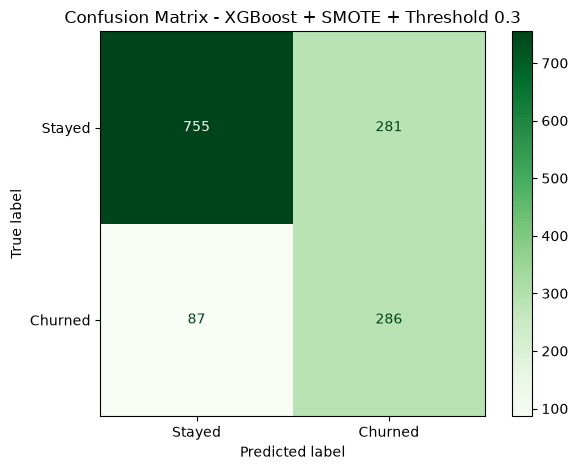

In [8]:
# Save the confusion matrix of the winning configuration
cm = confusion_matrix(y_test, y_pred_thresh)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - XGBoost + SMOTE + Threshold 0.3")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Compared with the baseline confusion matrix from Notebook 06, the bottom-left "missed churners" cell drops from 156 to 87. The top-right "false alarms" cell rises from 99 to 281, which is the cost of that improvement.

## Section conclusion — how we lifted recall from 0.58 to 0.77

- A more powerful model alone (**Random Forest**) did *not* help — recall actually fell to 0.46.
- **SMOTE** (balancing the training data) lifted Random Forest recall to 0.58.
- **XGBoost + SMOTE** reached 0.62 recall at the default threshold, ahead of Random Forest + SMOTE.
- **Lowering the decision threshold to 0.3** pushed recall to **0.77**, meeting the ≥70% business target.

**Next:** Notebook 08 trains this winning configuration as the final model and saves it for reuse.